A1: PURCHASE DATA ANALYSIS

Dataset shape: (10, 22)
Dimensionality of vector space: 3
Number of vectors in this vector space: 10

Rank of feature matrix: 3

Product costs (using pseudo-inverse):
Candies (Rs/piece): Rs 1.00
Mangoes (Rs/kg): Rs 55.00
Milk Packets (Rs/packet): Rs 18.00

A2: CUSTOMER CLASSIFICATION (RICH/POOR)

Classifier Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

        POOR       1.00      1.00      1.00         1
        RICH       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


Sample of classified customers:
 Candies (#)  Mangoes (Kg)  Milk Packets (#)  Payment (Rs) Customer_Class
          20             6                 2           386           RICH
          16             3                 6           289           RICH
          27             6             

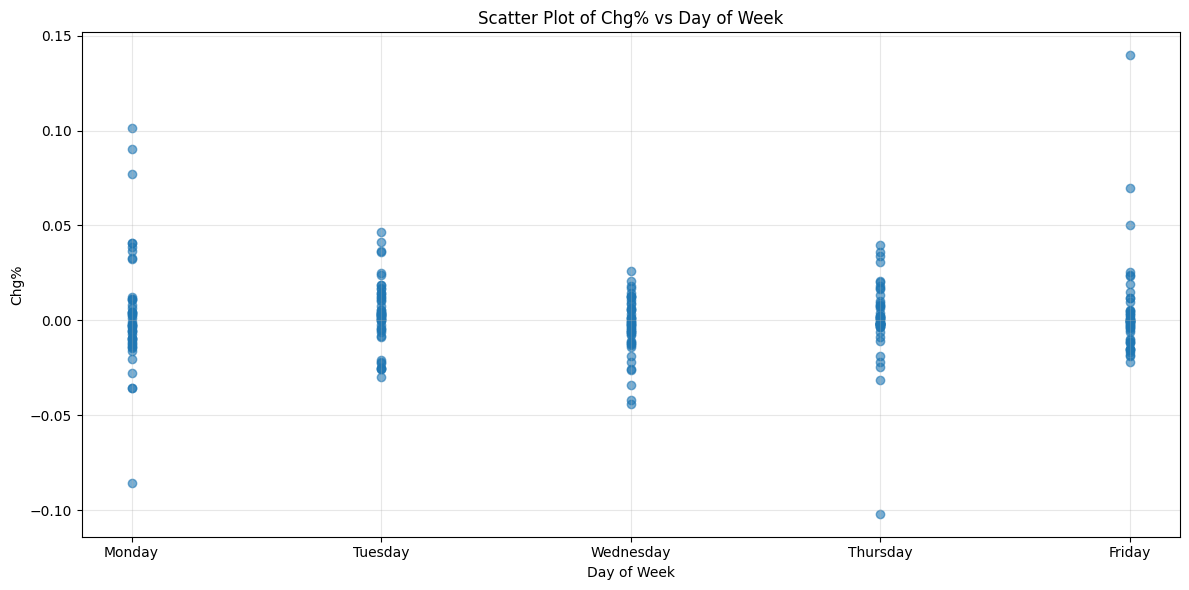


A4: THYROID DATA EXPLORATION

Dataset shape: (9172, 31)

Columns and their data types:
Record ID                     int64
age                           int64
sex                             str
on thyroxine                    str
query on thyroxine              str
on antithyroid medication       str
sick                            str
pregnant                        str
thyroid surgery                 str
I131 treatment                  str
query hypothyroid               str
query hyperthyroid              str
lithium                         str
goitre                          str
tumor                           str
hypopituitary                   str
psych                           str
TSH measured                    str
TSH                          object
T3 measured                     str
T3                           object
TT4 measured                    str
TT4                          object
T4U measured                    str
T4U                          object
FTI measured

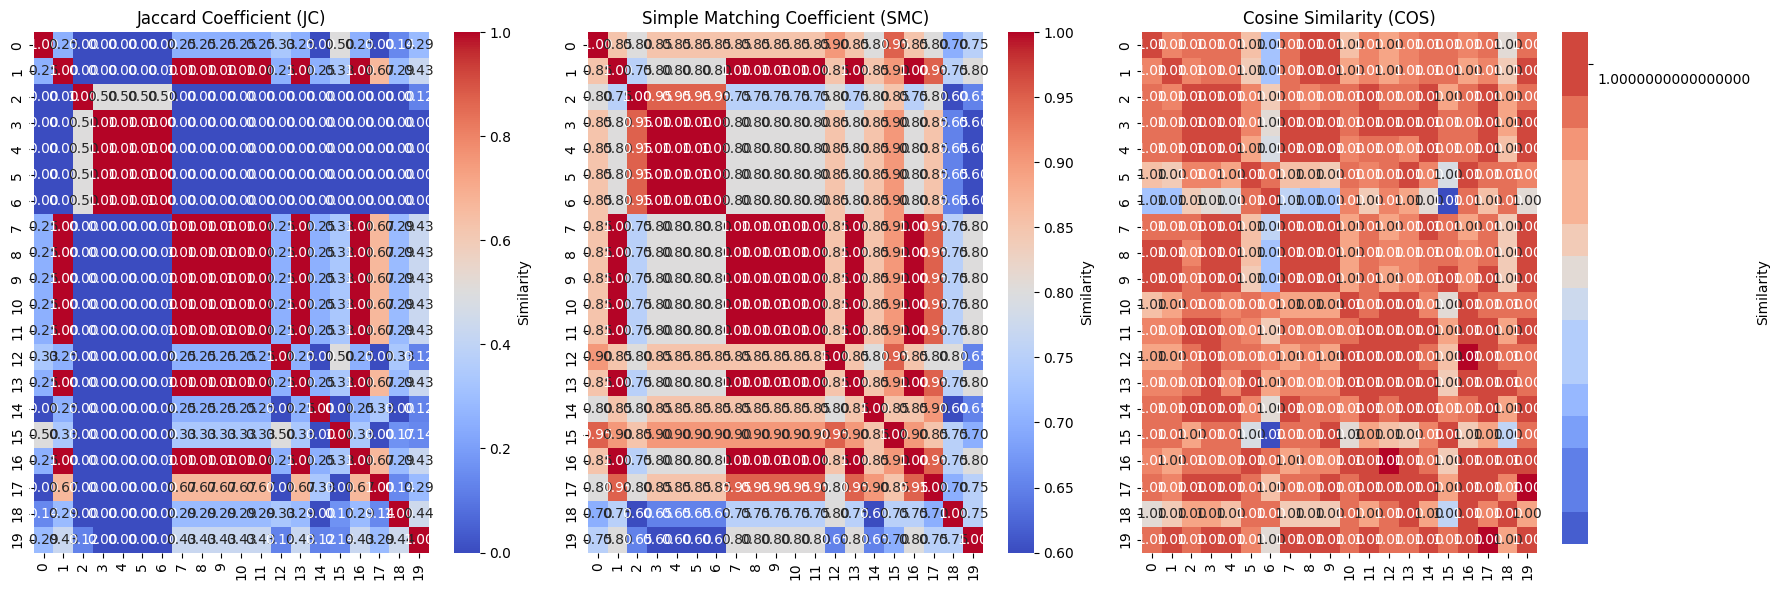


A8: DATA IMPUTATION
Imputation Strategy:
Record ID: Mean imputation (no outliers)
age: Median imputation (outliers present)
sex: Mode imputation (value: F)
TSH: Mode imputation (value: ?)
T3: Mode imputation (value: ?)
TT4: Mode imputation (value: ?)
T4U: Mode imputation (value: ?)
FTI: Mode imputation (value: ?)
TBG: Mode imputation (value: ?)
referral source: Mode imputation (value: other)
Condition: Mode imputation (value: NO CONDITION)

Null values after imputation: 0

A9: DATA NORMALIZATION / SCALING
Attributes that need normalization (numeric variables with large ranges):
Record ID: range = 29318022.00 (needs normalization)
age: range = 65525.00 (needs normalization)

Original numeric data statistics:
         Record ID        age
mean  8.529473e+08    73.5558
std   7.581969e+06  1183.9767

Normalized numeric data statistics:
      Record ID     age
mean     0.0000  0.0000
std      1.0001  1.0001


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

FILE_PATH = r"C:\Users\thanu\Downloads\Lab Session Data (1).xlsx"

# =============================================================================
# A1: Purchase Data Analysis
# =============================================================================

df_purchase = pd.read_excel(FILE_PATH, sheet_name='Purchase data')
X = df_purchase[['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)']].values
y = df_purchase['Payment (Rs)'].values

print("="*80)
print("A1: PURCHASE DATA ANALYSIS")
print("="*80)
print(f"\nDataset shape: {df_purchase.shape}")
print(f"Dimensionality of vector space: {X.shape[1]}")
print(f"Number of vectors in this vector space: {X.shape[0]}")

rank = np.linalg.matrix_rank(X)
print(f"\nRank of feature matrix: {rank}")

X_pinv = np.linalg.pinv(X)
costs = X_pinv @ y
print("\nProduct costs (using pseudo-inverse):")
product_names = ['Candies (Rs/piece)', 'Mangoes (Rs/kg)', 'Milk Packets (Rs/packet)']
for name, cost in zip(product_names, costs):
    print(f"{name}: Rs {cost:.2f}")

# =============================================================================
# A2: Customer Classification (RICH/POOR)
# =============================================================================

df_purchase['Customer_Class'] = df_purchase['Payment (Rs)'].apply(lambda x: 'RICH' if x > 200 else 'POOR')
y_class = df_purchase['Customer_Class'].map({'RICH': 1, 'POOR': 0}).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.3, random_state=42, stratify=y_class
)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*80)
print("A2: CUSTOMER CLASSIFICATION (RICH/POOR)")
print("="*80)
print(f"\nClassifier Accuracy: {accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['POOR', 'RICH']))

print("\nSample of classified customers:")
print(df_purchase[['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)', 'Payment (Rs)', 'Customer_Class']].head(10).to_string(index=False))

# =============================================================================
# A3: IRCTC Stock Price Analysis
# =============================================================================

df_stock = pd.read_excel(FILE_PATH, sheet_name='IRCTC Stock Price')
price_data = df_stock['Price'].dropna().values
chg_percent = df_stock['Chg%'].dropna().values

def calculate_mean_manual(data):
    return sum(data) / len(data) if len(data) > 0 else 0

def calculate_variance_manual(data, mean=None):
    if len(data) <= 1:
        return 0
    if mean is None:
        mean = calculate_mean_manual(data)
    return sum((x - mean) ** 2 for x in data) / len(data)

def measure_execution_time(func, data):
    times = []
    for _ in range(10):
        start_time = time.time()
        func(data)
        end_time = time.time()
        times.append(end_time - start_time)
    return np.mean(times)

mean_package = np.mean(price_data)
var_package = np.var(price_data)
mean_manual = calculate_mean_manual(price_data)
var_manual = calculate_variance_manual(price_data)

print("\n" + "="*80)
print("A3: IRCTC STOCK PRICE ANALYSIS")
print("="*80)
print(f"\nPrice Data Statistics:")
print(f"Package Mean: {mean_package:.4f}")
print(f"Manual Mean: {mean_manual:.4f}")
print(f"Package Variance: {var_package:.4f}")
print(f"Manual Variance: {var_manual:.4f}")

time_package = measure_execution_time(np.mean, price_data)
time_manual = measure_execution_time(calculate_mean_manual, price_data)
print(f"\nComputational Complexity (Average time over 10 runs):")
print(f"Package mean: {time_package:.6f} seconds")
print(f"Manual mean: {time_manual:.6f} seconds")

df_stock['Date'] = pd.to_datetime(df_stock['Date'])
df_stock['DayOfWeek'] = df_stock['Date'].dt.day_name()

wednesday_data = df_stock[df_stock['DayOfWeek'] == 'Wednesday']['Price'].dropna().values
apr_data = df_stock[df_stock['Month'] == 'Apr']['Price'].dropna().values

wednesday_mean = np.mean(wednesday_data) if len(wednesday_data) > 0 else 0
apr_mean = np.mean(apr_data) if len(apr_data) > 0 else 0

print(f"\nWednesday Sample Mean: {wednesday_mean:.4f}")
print(f"April Sample Mean: {apr_mean:.4f}")
print(f"Population Mean: {mean_package:.4f}")
print(f"Difference (Wednesday - Population): {wednesday_mean - mean_package:.4f}")
print(f"Difference (April - Population): {apr_mean - mean_package:.4f}")

loss_count = sum(1 for x in chg_percent if x < 0)
total_count = len(chg_percent)
prob_loss = loss_count / total_count if total_count > 0 else 0
print(f"\nProbability of making a loss: {prob_loss:.4f} ({prob_loss*100:.2f}%)")

wednesday_chg = df_stock[df_stock['DayOfWeek'] == 'Wednesday']['Chg%'].dropna().values
wednesday_profit = sum(1 for x in wednesday_chg if x > 0)
wednesday_total = len(wednesday_chg)
prob_profit_wednesday = wednesday_profit / wednesday_total if wednesday_total > 0 else 0
print(f"Probability of making profit on Wednesday: {prob_profit_wednesday:.4f} ({prob_profit_wednesday*100:.2f}%)")

all_profit = sum(1 for x in chg_percent if x > 0)
all_total = len(chg_percent)
prob_profit = all_profit / all_total if all_total > 0 else 0
prob_wednesday = wednesday_total / total_count if total_count > 0 else 0
conditional_prob = prob_profit_wednesday / prob_wednesday if prob_wednesday > 0 else 0
print(f"Conditional probability of profit given Wednesday: {conditional_prob:.4f} ({conditional_prob*100:.2f}%)")

plt.figure(figsize=(12, 6))
day_mapping = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4}
df_stock['DayNum'] = df_stock['DayOfWeek'].map(day_mapping)
plt.scatter(df_stock['DayNum'], df_stock['Chg%'], alpha=0.6)
plt.xlabel('Day of Week')
plt.ylabel('Chg%')
plt.title('Scatter Plot of Chg% vs Day of Week')
plt.xticks(list(day_mapping.values()), list(day_mapping.keys()))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# A4: Thyroid Data Exploration
# =============================================================================

df_thyroid = pd.read_excel(FILE_PATH, sheet_name='thyroid0387_UCI')

print("\n" + "="*80)
print("A4: THYROID DATA EXPLORATION")
print("="*80)
print(f"\nDataset shape: {df_thyroid.shape}")
print(f"\nColumns and their data types:")
print(df_thyroid.dtypes)

print("\n\nAttribute Analysis:")
for col in df_thyroid.columns:
    unique_values = df_thyroid[col].nunique()
    null_count = df_thyroid[col].isnull().sum()
    dtype = df_thyroid[col].dtype
    
    if dtype == 'object' or unique_values < 10:
        data_type = "Categorical"
        if unique_values <= 3:
            encoding = "Label Encoding (ordinal)" if unique_values == 2 else "One-Hot Encoding (nominal)"
        else:
            encoding = "One-Hot Encoding (nominal)"
    else:
        data_type = "Numeric"
        encoding = "Standardization/Normalization"
    
    print(f"\n{col}:")
    print(f"  Data Type: {data_type}")
    print(f"  Unique Values: {unique_values}")
    print(f"  Null Count: {null_count}")
    print(f"  Recommended Encoding: {encoding}")
    
    if data_type == "Numeric":
        valid_data = df_thyroid[col].dropna()
        if len(valid_data) > 0:
            try:
                print(f"  Range: {valid_data.min():.2f} to {valid_data.max():.2f}")
                print(f"  Mean: {valid_data.mean():.2f}")
                print(f"  Standard Deviation: {valid_data.std():.2f}")
            except:
                print(f"  Could not compute statistics for {col}")

# Check for outliers using IQR method
print("\n\nOutlier Detection for Numeric Variables:")
numeric_cols = df_thyroid.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    valid_data = df_thyroid[col].dropna()
    if len(valid_data) > 0:
        try:
            Q1 = valid_data.quantile(0.25)
            Q3 = valid_data.quantile(0.75)
            IQR = Q3 - Q1
            outliers = valid_data[(valid_data < Q1 - 1.5 * IQR) | (valid_data > Q3 + 1.5 * IQR)]
            print(f"{col}: {len(outliers)} outliers detected ({(len(outliers)/len(valid_data))*100:.2f}%)")
        except:
            print(f"{col}: Could not compute outliers")

# =============================================================================
# A5: Similarity Measures (Jaccard & SMC)
# =============================================================================

print("\n" + "="*80)
print("A5: SIMILARITY MEASURES (JACCARD & SMC)")
print("="*80)

binary_cols = ['on thyroxine', 'query on thyroxine', 'on antithyroid medication', 
               'sick', 'pregnant', 'thyroid surgery', 'I131 treatment', 
               'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre', 
               'tumor', 'hypopituitary', 'psych', 'TSH measured', 'T3 measured', 
               'TT4 measured', 'T4U measured', 'FTI measured', 'TBG measured']

# Filter binary columns that exist in the dataframe
binary_cols_exist = [col for col in binary_cols if col in df_thyroid.columns]

first_two = df_thyroid.head(2)
binary_df = first_two[binary_cols_exist].replace({'f': 0, 't': 1, '?': 0})

vec1 = binary_df.iloc[0].values
vec2 = binary_df.iloc[1].values

f11 = sum((vec1 == 1) & (vec2 == 1))
f10 = sum((vec1 == 1) & (vec2 == 0))
f01 = sum((vec1 == 0) & (vec2 == 1))
f00 = sum((vec1 == 0) & (vec2 == 0))

JC = f11 / (f01 + f10 + f11) if (f01 + f10 + f11) > 0 else 0
SMC = (f11 + f00) / (f00 + f01 + f10 + f11) if (f00 + f01 + f10 + f11) > 0 else 0

print(f"\nBinary vectors for first two observations:")
print(f"Vector 1 length: {len(vec1)}")
print(f"Vector 2 length: {len(vec2)}")
print(f"\nContingency Table:")
print(f"f11 (both 1): {f11}")
print(f"f10 (1,0): {f10}")
print(f"f01 (0,1): {f01}")
print(f"f00 (both 0): {f00}")
print(f"\nJaccard Coefficient (JC): {JC:.4f}")
print(f"Simple Matching Coefficient (SMC): {SMC:.4f}")

if JC > SMC:
    print("\nJC > SMC, indicating sparse positive matches.")
else:
    print("\nSMC > JC, indicating many negative matches.")

# =============================================================================
# A6: Cosine Similarity
# =============================================================================

print("\n" + "="*80)
print("A6: COSINE SIMILARITY")
print("="*80)

first_two_complete = df_thyroid.head(2)
numeric_cols_complete = first_two_complete.select_dtypes(include=[np.number]).columns
vec1_complete = first_two_complete[numeric_cols_complete].iloc[0].fillna(0).values
vec2_complete = first_two_complete[numeric_cols_complete].iloc[1].fillna(0).values

dot_product = np.dot(vec1_complete, vec2_complete)
norm1 = np.linalg.norm(vec1_complete)
norm2 = np.linalg.norm(vec2_complete)
cosine_sim = dot_product / (norm1 * norm2) if (norm1 * norm2) > 0 else 0

print(f"\nUsing complete vectors (including all numeric attributes):")
print(f"Cosine Similarity: {cosine_sim:.4f}")

# =============================================================================
# A7: Heatmap Plot for Similarity Measures
# =============================================================================

print("\n" + "="*80)
print("A7: HEATMAP PLOT FOR SIMILARITY MEASURES")
print("="*80)

first_20 = df_thyroid.head(20)
binary_cols_20 = [col for col in binary_cols_exist if col in first_20.columns]
binary_20 = first_20[binary_cols_20].replace({'f': 0, 't': 1, '?': 0}).values
numeric_20 = first_20.select_dtypes(include=[np.number]).fillna(0).values

n = 20
JC_matrix = np.zeros((n, n))
SMC_matrix = np.zeros((n, n))
COS_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i == j:
            JC_matrix[i, j] = 1
            SMC_matrix[i, j] = 1
            COS_matrix[i, j] = 1
        else:
            vec1_bin = binary_20[i]
            vec2_bin = binary_20[j]
            f11_bin = sum((vec1_bin == 1) & (vec2_bin == 1))
            f10_bin = sum((vec1_bin == 1) & (vec2_bin == 0))
            f01_bin = sum((vec1_bin == 0) & (vec2_bin == 1))
            f00_bin = sum((vec1_bin == 0) & (vec2_bin == 0))
            JC_matrix[i, j] = f11_bin / (f01_bin + f10_bin + f11_bin) if (f01_bin + f10_bin + f11_bin) > 0 else 0
            SMC_matrix[i, j] = (f11_bin + f00_bin) / (f00_bin + f01_bin + f10_bin + f11_bin) if (f00_bin + f01_bin + f10_bin + f11_bin) > 0 else 0
            
            vec1_num = numeric_20[i]
            vec2_num = numeric_20[j]
            dot = np.dot(vec1_num, vec2_num)
            n1 = np.linalg.norm(vec1_num)
            n2 = np.linalg.norm(vec2_num)
            COS_matrix[i, j] = dot / (n1 * n2) if (n1 * n2) > 0 else 0

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.heatmap(JC_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0], cbar_kws={'label': 'Similarity'})
axes[0].set_title('Jaccard Coefficient (JC)')
sns.heatmap(SMC_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1], cbar_kws={'label': 'Similarity'})
axes[1].set_title('Simple Matching Coefficient (SMC)')
sns.heatmap(COS_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[2], cbar_kws={'label': 'Similarity'})
axes[2].set_title('Cosine Similarity (COS)')
plt.tight_layout()
plt.show()

# =============================================================================
# A8: Data Imputation
# =============================================================================

print("\n" + "="*80)
print("A8: DATA IMPUTATION")
print("="*80)

df_thyroid_imputed = df_thyroid.copy()
numeric_cols_full = df_thyroid_imputed.select_dtypes(include=[np.number]).columns

print("Imputation Strategy:")
for col in df_thyroid_imputed.columns:
    if col in ['Condition', 'referral source', 'sex'] or df_thyroid_imputed[col].dtype == 'object':
        mode_value = df_thyroid_imputed[col].mode()
        if len(mode_value) > 0:
            df_thyroid_imputed[col] = df_thyroid_imputed[col].fillna(mode_value[0])
            print(f"{col}: Mode imputation (value: {mode_value[0]})")
    elif col in numeric_cols_full:
        valid_data = df_thyroid_imputed[col].dropna()
        if len(valid_data) > 0:
            try:
                Q1 = valid_data.quantile(0.25)
                Q3 = valid_data.quantile(0.75)
                IQR = Q3 - Q1
                outliers = valid_data[(valid_data < Q1 - 1.5 * IQR) | (valid_data > Q3 + 1.5 * IQR)]
                if len(outliers) > 0:
                    median_value = valid_data.median()
                    df_thyroid_imputed[col] = df_thyroid_imputed[col].fillna(median_value)
                    print(f"{col}: Median imputation (outliers present)")
                else:
                    mean_value = valid_data.mean()
                    df_thyroid_imputed[col] = df_thyroid_imputed[col].fillna(mean_value)
                    print(f"{col}: Mean imputation (no outliers)")
            except:
                median_value = valid_data.median()
                df_thyroid_imputed[col] = df_thyroid_imputed[col].fillna(median_value)
                print(f"{col}: Median imputation (error with statistics)")

print(f"\nNull values after imputation: {df_thyroid_imputed.isnull().sum().sum()}")

# =============================================================================
# A9: Data Normalization / Scaling
# =============================================================================

print("\n" + "="*80)
print("A9: DATA NORMALIZATION / SCALING")
print("="*80)

print("Attributes that need normalization (numeric variables with large ranges):")
for col in numeric_cols_full:
    valid_data = df_thyroid_imputed[col].dropna()
    if len(valid_data) > 0:
        try:
            range_val = valid_data.max() - valid_data.min()
            if range_val > 100:
                print(f"{col}: range = {range_val:.2f} (needs normalization)")
        except:
            pass

numeric_data = df_thyroid_imputed[numeric_cols_full]
scaler = StandardScaler()
normalized_data = scaler.fit_transform(numeric_data)
normalized_df = pd.DataFrame(normalized_data, columns=numeric_cols_full)

print("\nOriginal numeric data statistics:")
print(numeric_data.describe().loc[['mean', 'std']].round(4))

print("\nNormalized numeric data statistics:")
print(normalized_df.describe().loc[['mean', 'std']].round(4))


